<a href="https://colab.research.google.com/github/Nois12/AIFFEL_quest_rs/blob/main/GoingDeeper/Gd02/Object_Detection_System_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 자율주행 보조 시스템 만들기

목적 : 카메라 영상에서 사람과 차량을 감지해, 위험 상황이면 멈추도록 판단하는 미니 자율주행 보조 장치를 만드는 것
(KITTI 데이터셋으로 RetinaNet(Focal Loss + FPN)을 구현/학습하고, 학습된 모델과 torchvision의 사전학습 RetinaNet(COCO)을 이용해 최종 자율주행 보조 시스템까지 완성한다)

> 자율주행 보조장치 object detection 요구사항
> 1. 사람이 카메라에 감지되면 정지
> 2. 차량이 일정 크기 이상으로 감지되면 정지



In [ ]:
import os
os.makedirs(os.path.expanduser('~/aiffel/object_detection/data'), exist_ok=True)

In [ ]:
import os
import copy

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as NF
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.models as models
from torchvision.models import ResNet50_Weights
from torchvision.ops import nms
from torchvision.models.detection import retinanet_resnet50_fpn, RetinaNet_ResNet50_FPN_Weights

from google.colab import files

matplotlib.rcParams['axes.unicode_minus'] = False
torch._orig_load = getattr(torch, '_orig_load', torch.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return torch._orig_load(*a, **k)
torch.load = _compat_load

DATA_PATH = '/content/object_detection/data'
os.makedirs(DATA_PATH, exist_ok=True)

print('라이브러리 불러오기 완료')

라이브러리 불러오기 완료


## KITTI 데이터셋 준비 및 구조 파악


In [ ]:
import shutil, os

kitti_dir = os.path.join(DATA_PATH, 'Kitti')
if os.path.exists(kitti_dir):
    shutil.rmtree(kitti_dir)
    print(f"{kitti_dir} 삭제 완료 — 다시 다운로드하면 됩니다.")
else:
    print("삭제할 캐시가 없습니다.")

/content/object_detection/data/Kitti 삭제 완료 — 다시 다운로드하면 됩니다.


In [ ]:
kitti_train = torchvision.datasets.Kitti(root=DATA_PATH, train=True, download=True)
kitti_test  = torchvision.datasets.Kitti(root=DATA_PATH, train=False, download=True)

KITTI_CLASSES = ['Car', 'Van', 'Truck', 'Pedestrian',
                 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
NAME_TO_ID = {name: i for i, name in enumerate(KITTI_CLASSES)}

def parse_kitti_target(target):
    """torchvision KITTI 타깃(list of dict) -> (boxes[xyxy px], class_ids)."""
    boxes, cls_ids = [], []
    for obj in (target or []):
        name = obj['type']
        if name not in NAME_TO_ID:
            continue
        boxes.append(obj['bbox'])
        cls_ids.append(NAME_TO_ID[name])
    boxes = torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)
    cls_ids = torch.tensor(cls_ids, dtype=torch.int64)
    return boxes, cls_ids

print(f"train 이미지 수: {len(kitti_train)}")
print(f"test  이미지 수: {len(kitti_test)}")
print(f"클래스({len(KITTI_CLASSES)}개): {KITTI_CLASSES}")

100%|██████████| 12.6G/12.6G [02:26<00:00, 85.6MB/s]
100%|██████████| 5.60M/5.60M [00:00<00:00, 83.4MB/s]


train 이미지 수: 7481
test  이미지 수: 7518
클래스(8개): ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']


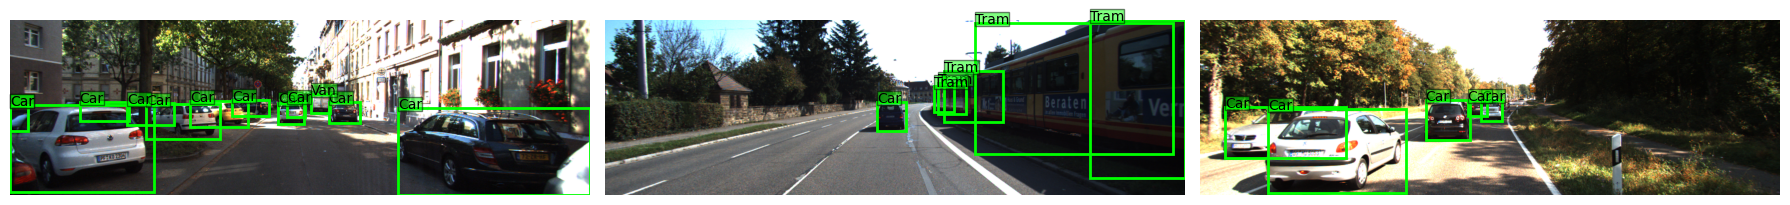

In [ ]:
# 학습 데이터 몇 장을 바운딩 박스와 함께 직접 그림
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, idx in zip(axes, range(3)):
    image, target = kitti_train[idx]
    ax.imshow(image)
    for obj in target:
        if obj['type'] not in NAME_TO_ID:
            continue
        x1, y1, x2, y2 = obj['bbox']
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   fill=False, edgecolor='lime', linewidth=2))
        ax.text(x1, y1, obj['type'], color='black',
                bbox={'facecolor': 'lime', 'alpha': 0.5, 'pad': 0})
    ax.axis('off')
plt.tight_layout()
plt.show()

### 데이터 하나 직접 확인하기


------ target(첫 번째 객체) ------
{'type': 'Car', 'truncated': 0.0, 'occluded': 0, 'alpha': -1.54, 'bbox': [572.99, 176.63, 629.55, 222.6], 'dimensions': [1.36, 1.69, 3.38], 'location': [-0.27, 1.5, 23.37], 'rotation_y': -1.55}
------ 파싱 결과 ------
boxes(xyxy, px): torch.Size([12, 4])
class_ids     : [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


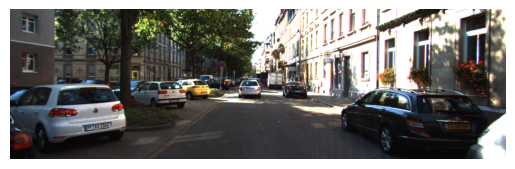

In [ ]:
# kitti_train[0] 으로 (이미지, 타깃) 하나를 뽑아 직접 확인
image, target = kitti_train[0]

print('------ target(첫 번째 객체) ------')
print(target[0])

boxes, cls_ids = parse_kitti_target(target)
print('------ 파싱 결과 ------')
print('boxes(xyxy, px):', boxes.shape)
print('class_ids     :', cls_ids.tolist())

plt.imshow(image)
plt.axis('off')
plt.show()

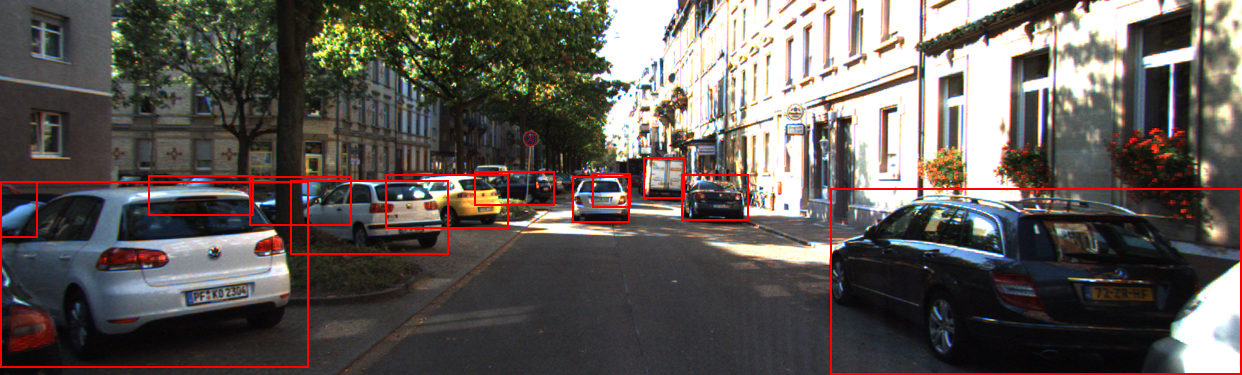

In [ ]:
# 이미지 위에 바운딩 박스를 그려 화면에 표시
def visualize_bbox(input_image, target):
    input_image = copy.deepcopy(input_image)
    draw = ImageDraw.Draw(input_image)

    for obj in target:
        if obj['type'] not in NAME_TO_ID:
            continue
        x_min, y_min, x_max, y_max = obj['bbox']
        draw.rectangle((x_min, y_min, x_max, y_max), outline=(255, 0, 0), width=2)

    return input_image

visualize_bbox(image, target)

## RetinaNet



## 데이터 전처리 파이프라인

KITTI 데이터를 학습에 맞는 형태로 바꾸는 파이프라인
1. 무작위 수평 뒤집기(flip)
2. 이미지 크기 조정 및 패딩(stride의 배수로 맞춤)
3. 좌표계를 `[x_min, y_min, x_max, y_max]` → `[cx, cy, w, h]`로 변환


In [ ]:
def random_flip_horizontal(image, boxes):

    if torch.rand(1).item() > 0.5:
        _, _, width = image.shape
        image = TF.hflip(image)
        boxes = torch.stack(
            [width - boxes[:, 2], boxes[:, 1], width - boxes[:, 0], boxes[:, 3]], dim=-1
        )
    return image, boxes

In [ ]:
def resize_and_pad_image(image, training=True):

    min_side = 800.0
    max_side = 1333.0
    min_side_range = [640, 1024]
    stride = 128.0

    image_shape = torch.tensor(image.shape[-2:], dtype=torch.float32)  # [H, W]
    if training:
        min_side = torch.empty(1).uniform_(min_side_range[0], min_side_range[1]).item()
    ratio = min_side / torch.min(image_shape)
    if ratio * torch.max(image_shape) > max_side:
        ratio = max_side / torch.max(image_shape)
    new_shape = ratio * image_shape
    new_size = [int(new_shape[0].round().item()), int(new_shape[1].round().item())]  # [H', W']
    image = TF.resize(image, new_size)

    padded = (torch.ceil(new_shape / stride) * stride).int().tolist()
    pad_h = padded[0] - new_size[0]
    pad_w = padded[1] - new_size[1]
    image = TF.pad(image, [0, 0, pad_w, pad_h])  # (left, top, right, bottom)
    return image, torch.tensor(new_size, dtype=torch.float32), float(ratio)

In [ ]:
def convert_to_xywh(boxes):
    return torch.cat(
        [(boxes[..., :2] + boxes[..., 2:]) / 2.0,
         boxes[..., 2:] - boxes[..., :2]],
        dim=-1
    )

In [ ]:
def preprocess_data(image, boxes, class_ids):

    image, boxes = random_flip_horizontal(image, boxes)
    image, _, ratio = resize_and_pad_image(image)

    boxes = boxes * ratio
    boxes = convert_to_xywh(boxes)
    return image, boxes, class_ids

### Anchor Box 와 인코딩


In [ ]:
class AnchorBox:
    """RetinaNet은 이 anchor들을 기준으로 '어느 anchor가 물체인가/배경인가'와
    'anchor 대비 GT box가 얼마나 어긋나 있는가'를 예측하도록 학습된다.
    """

    def __init__(self):
        self.aspect_ratios = [0.5, 1.0, 2.0]
        self.scales = [2 ** x for x in [0, 1 / 3, 2 / 3]]

        self._num_anchors = len(self.aspect_ratios) * len(self.scales)
        self._strides = [2 ** i for i in range(3, 8)]
        self._areas = [x ** 2 for x in [32.0, 64.0, 128.0, 256.0, 512.0]]
        self._anchor_dims = self._compute_dims()

    def _compute_dims(self):
        anchor_dims_all = []
        for area in self._areas:
            anchor_dims = []
            for ratio in self.aspect_ratios:
                anchor_height = torch.sqrt(torch.tensor(area, dtype=torch.float32) / torch.tensor(ratio, dtype=torch.float32))
                anchor_width = torch.tensor(area, dtype=torch.float32) / anchor_height
                dims = torch.stack([anchor_width, anchor_height], dim=-1).view(1, 1, 2)
                for scale in self.scales:
                    anchor_dims.append(scale * dims)
            anchor_dims_all.append(torch.stack(anchor_dims, dim=-2))
        return anchor_dims_all

    def _get_anchors(self, feature_height, feature_width, level):
        rx = torch.arange(feature_width, dtype=torch.float32) + 0.5
        ry = torch.arange(feature_height, dtype=torch.float32) + 0.5
        cx, cy = torch.meshgrid(rx, ry, indexing='xy')
        centers = torch.stack([cx, cy], dim=-1) * self._strides[level - 3]
        centers = centers.unsqueeze(-2)
        centers = centers.repeat(1, 1, self._num_anchors, 1)
        dims = self._anchor_dims[level - 3].repeat(feature_height, feature_width, 1, 1)
        anchors = torch.cat([centers, dims], dim=-1)
        return anchors.view(feature_height * feature_width * self._num_anchors, 4)

    def get_anchors(self, image_height, image_width):
        anchors = [
            self._get_anchors(
                int(image_height / 2 ** i),
                int(image_width / 2 ** i),
                i,
            )
            for i in range(3, 8)
        ]
        return torch.cat(anchors, dim=0)

In [ ]:
def convert_to_corners(boxes):
    return torch.cat(
        [boxes[..., :2] - boxes[..., 2:] / 2.0, boxes[..., :2] + boxes[..., 2:] / 2.0],
        dim=-1,
    )

def compute_iou(boxes1, boxes2):
    boxes1_corners = convert_to_corners(boxes1)
    boxes2_corners = convert_to_corners(boxes2)
    lu = torch.maximum(boxes1_corners[:, None, :2], boxes2_corners[:, :2])
    rd = torch.minimum(boxes1_corners[:, None, 2:], boxes2_corners[:, 2:])
    intersection = torch.maximum(torch.tensor(0.0), rd - lu)
    intersection_area = intersection[:, :, 0] * intersection[:, :, 1]
    boxes1_area = boxes1[:, 2] * boxes1[:, 3]
    boxes2_area = boxes2[:, 2] * boxes2[:, 3]
    union_area = torch.maximum(
        boxes1_area[:, None] + boxes2_area - intersection_area, torch.tensor(1e-8)
    )
    return torch.clamp(intersection_area / union_area, min=0.0, max=1.0)

In [ ]:
class LabelEncoder:

    def __init__(self):
        self._anchor_box = AnchorBox()
        self._box_variance = torch.tensor([0.1, 0.1, 0.2, 0.2], dtype=torch.float32)

    def _match_anchor_boxes(self, anchor_boxes, gt_boxes, match_iou=0.5, ignore_iou=0.4):
        iou_matrix = compute_iou(anchor_boxes, gt_boxes)
        max_iou, matched_gt_idx = torch.max(iou_matrix, dim=1)
        positive_mask = (max_iou >= match_iou).float()
        negative_mask = max_iou < ignore_iou
        ignore_mask = (~((max_iou >= match_iou) | negative_mask)).float()
        return matched_gt_idx, positive_mask, ignore_mask

    def _compute_box_target(self, anchor_boxes, matched_gt_boxes):
        box_target = torch.cat(
            [
                (matched_gt_boxes[:, :2] - anchor_boxes[:, :2]) / anchor_boxes[:, 2:],
                torch.log(matched_gt_boxes[:, 2:] / anchor_boxes[:, 2:]),
            ],
            dim=-1,
        )
        return box_target / self._box_variance

    def _encode_sample(self, image_shape, gt_boxes, cls_ids):

        anchor_boxes = self._anchor_box.get_anchors(image_shape[0], image_shape[1])

        if gt_boxes.numel() == 0:
            box_target = torch.zeros_like(anchor_boxes)
            cls_target = torch.full((anchor_boxes.shape[0], 1), -1.0)
            return torch.cat([box_target, cls_target], dim=-1)

        cls_ids = cls_ids.float()
        matched_gt_idx, positive_mask, ignore_mask = self._match_anchor_boxes(anchor_boxes, gt_boxes)
        matched_gt_boxes = gt_boxes[matched_gt_idx]
        box_target = self._compute_box_target(anchor_boxes, matched_gt_boxes)
        matched_gt_cls_ids = cls_ids[matched_gt_idx]
        cls_target = torch.where(positive_mask != 1.0, torch.tensor(-1.0), matched_gt_cls_ids)
        cls_target = torch.where(ignore_mask == 1.0, torch.tensor(-2.0), cls_target)
        cls_target = cls_target.unsqueeze(-1)
        return torch.cat([box_target, cls_target], dim=-1)

    def encode_batch(self, batch_images, gt_boxes, cls_ids):

        N, _, H, W = batch_images.shape
        labels = [self._encode_sample((H, W), gt_boxes[i], cls_ids[i]) for i in range(N)]

        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        batch_images = (batch_images - mean) / std

        return batch_images, torch.stack(labels, dim=0)

## 모델 작성 (RetinaNet)

Backbone(ResNet50) → FPN → Classification/Box Regression Head

In [ ]:
class FeaturePyramid(nn.Module):

    def __init__(self, backbone):
        super(FeaturePyramid, self).__init__()
        self.backbone = backbone
        # ResNet50의 C3/C4/C5 채널 수는 각각 512 / 1024 / 2048
        self.conv_c3_1x1 = nn.Conv2d(512, 256, 1, 1, padding=0)
        self.conv_c4_1x1 = nn.Conv2d(1024, 256, 1, 1, padding=0)
        self.conv_c5_1x1 = nn.Conv2d(2048, 256, 1, 1, padding=0)
        self.conv_c3_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c4_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c5_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c6_3x3 = nn.Conv2d(2048, 256, 3, 2, padding=1)
        self.conv_c7_3x3 = nn.Conv2d(256, 256, 3, 2, padding=1)
        self.upsample_2x = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, images):
        c3_output, c4_output, c5_output = self.backbone(images)
        p3_output = self.conv_c3_1x1(c3_output)
        p4_output = self.conv_c4_1x1(c4_output)
        p5_output = self.conv_c5_1x1(c5_output)
        p4_output = p4_output + self.upsample_2x(p5_output)
        p3_output = p3_output + self.upsample_2x(p4_output)
        p3_output = self.conv_c3_3x3(p3_output)
        p4_output = self.conv_c4_3x3(p4_output)
        p5_output = self.conv_c5_3x3(p5_output)
        p6_output = self.conv_c6_3x3(c5_output)
        p7_output = self.conv_c7_3x3(NF.relu(p6_output))
        return p3_output, p4_output, p5_output, p6_output, p7_output

In [ ]:
def build_head(output_filters, bias_init):
    layers = []
    for _ in range(4):
        conv = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        nn.init.normal_(conv.weight, mean=0.0, std=0.01)
        nn.init.zeros_(conv.bias)
        layers.append(conv)
        layers.append(nn.ReLU())

    out_conv = nn.Conv2d(256, output_filters, kernel_size=3, stride=1, padding=1)
    nn.init.normal_(out_conv.weight, mean=0.0, std=0.01)
    if bias_init == "zeros":
        nn.init.zeros_(out_conv.bias)
    else:
        nn.init.constant_(out_conv.bias, float(bias_init))
    layers.append(out_conv)

    return nn.Sequential(*layers)

In [ ]:
class Backbone(nn.Module):
    """ResNet50에서 C3, C4, C5 특성 맵을 뽑아 반환하는 backbone."""
    def __init__(self):
        super(Backbone, self).__init__()
        base = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1
        self.layer2 = base.layer2   # C3 (stride 8,  512ch)
        self.layer3 = base.layer3   # C4 (stride 16, 1024ch)
        self.layer4 = base.layer4   # C5 (stride 32, 2048ch)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        c3 = self.layer2(x)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)
        return c3, c4, c5

def get_backbone():
    return Backbone()

In [ ]:
class RetinaNet(nn.Module):
    def __init__(self, num_classes, backbone):
        super(RetinaNet, self).__init__()
        self.fpn = FeaturePyramid(backbone)
        self.num_classes = num_classes

        prior_probability = -torch.log(torch.tensor((1 - 0.01) / 0.01))
        self.cls_head = build_head(9 * num_classes, prior_probability)
        self.box_head = build_head(9 * 4, "zeros")

    def forward(self, image):
        features = self.fpn(image)
        N = image.size(0)
        cls_outputs = []
        box_outputs = []
        for feature in features:

            box_outputs.append(self.box_head(feature).permute(0, 2, 3, 1).reshape(N, -1, 4))
            cls_outputs.append(self.cls_head(feature).permute(0, 2, 3, 1).reshape(N, -1, self.num_classes))
        cls_outputs = torch.cat(cls_outputs, dim=1)
        box_outputs = torch.cat(box_outputs, dim=1)
        return torch.cat([box_outputs, cls_outputs], dim=-1)

### Loss 함수

Box Regression -> Smooth L1 Loss

Classification -> Focal Loss(`alpha`, `gamma`)를 사용

In [ ]:
class RetinaNetBoxLoss(nn.Module):
    def __init__(self, delta):
        super(RetinaNetBoxLoss, self).__init__()
        self._delta = delta

    def forward(self, y_true, y_pred):
        difference = y_true - y_pred
        absolute_difference = torch.abs(difference)
        squared_difference = difference ** 2
        loss = torch.where(
            absolute_difference < self._delta,
            0.5 * squared_difference,
            absolute_difference - 0.5,
        )
        return torch.sum(loss, dim=-1)

class RetinaNetClassificationLoss(nn.Module):
    def __init__(self, alpha, gamma):
        super(RetinaNetClassificationLoss, self).__init__()
        self._alpha = alpha
        self._gamma = gamma

    def forward(self, y_true, y_pred):
        cross_entropy = NF.binary_cross_entropy_with_logits(y_pred, y_true, reduction='none')
        probs = torch.sigmoid(y_pred)
        alpha = torch.where(y_true == 1.0, torch.tensor(self._alpha), torch.tensor(1.0 - self._alpha))
        pt = torch.where(y_true == 1.0, probs, 1 - probs)
        loss = alpha * torch.pow(1.0 - pt, self._gamma) * cross_entropy
        return torch.sum(loss, dim=-1)

class RetinaNetLoss(nn.Module):
    def __init__(self, num_classes=8, alpha=0.25, gamma=2.0, delta=1.0):
        super(RetinaNetLoss, self).__init__()
        self._clf_loss = RetinaNetClassificationLoss(alpha, gamma)
        self._box_loss = RetinaNetBoxLoss(delta)
        self._num_classes = num_classes

    def forward(self, y_true, y_pred):

        box_labels = y_true[:, :, :4]
        box_predictions = y_pred[:, :, :4]
        cls_predictions = y_pred[:, :, 4:]

        cls_ids = y_true[:, :, 4]
        positive_mask = (cls_ids > -1.0).float()
        ignore_mask = (cls_ids == -2.0).float()

        cls_target_idx = cls_ids.clamp(min=0).long()
        cls_labels = NF.one_hot(cls_target_idx, num_classes=self._num_classes).float()
        cls_labels = cls_labels * positive_mask.unsqueeze(-1)

        clf_loss = self._clf_loss(cls_labels, cls_predictions)
        box_loss = self._box_loss(box_labels, box_predictions)

        clf_loss = torch.where(ignore_mask == 1.0, torch.zeros_like(clf_loss), clf_loss)
        box_loss = torch.where(positive_mask == 1.0, box_loss, torch.zeros_like(box_loss))

        normalizer = torch.clamp(positive_mask.sum(dim=-1), min=1.0)
        clf_loss = clf_loss.sum(dim=-1) / normalizer
        box_loss = box_loss.sum(dim=-1) / normalizer

        return (clf_loss + box_loss).mean()

## 모델 학습



In [ ]:
num_classes = 8
batch_size = 2

resnet50_backbone = get_backbone()
loss_fn = RetinaNetLoss(num_classes)
model = RetinaNet(num_classes, resnet50_backbone)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 277MB/s]


In [ ]:
learning_rates = [2.5e-06, 0.000625, 0.00125, 0.0025, 0.00025, 2.5e-05]
learning_rate_boundaries = [125, 250, 500, 240000, 360000]
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rates[0], momentum=0.9)

def lr_lambda(epoch):
    for i, boundary in enumerate(learning_rate_boundaries):
        if epoch < boundary:
            return learning_rates[i] / learning_rates[0]
    return learning_rates[-1] / learning_rates[0]

scheduler = LambdaLR(optimizer, lr_lambda)

In [ ]:
label_encoder = LabelEncoder()

class KITTIDetection(Dataset):
    """torchvision KITTI를 감싸 (image_tensor, boxes_xywh, class_ids)를 반환하는 Dataset."""
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, target = self.base[idx]          # PIL image, list of dict
        boxes, class_ids = parse_kitti_target(target)
        image = TF.to_tensor(image)             # [3, H, W], 0~1
        image, boxes, class_ids = preprocess_data(image, boxes, class_ids)
        return image, boxes, class_ids

def make_collate_fn(label_encoder):

    def collate_fn(batch):
        images, boxes, cls_ids = zip(*batch)
        max_h = max(img.shape[1] for img in images)
        max_w = max(img.shape[2] for img in images)

        padded = []
        for img in images:
            pad_h = max_h - img.shape[1]
            pad_w = max_w - img.shape[2]
            padded.append(NF.pad(img, (0, pad_w, 0, pad_h)))
        images = torch.stack(padded)

        images, labels = label_encoder.encode_batch(images, list(boxes), list(cls_ids))
        return images, labels
    return collate_fn

# 학습/검증 분할
full_dataset = KITTIDetection(kitti_train)
val_size = max(1, int(len(full_dataset) * 0.1))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

collate_fn = make_collate_fn(label_encoder)
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, drop_last=True,
    collate_fn=collate_fn, num_workers=2
)
val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False, drop_last=True,
    collate_fn=collate_fn, num_workers=2
)

In [ ]:
model_dir = os.path.join(DATA_PATH, "checkpoints")
os.makedirs(model_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 5
for epoch in range(epochs):
    model.train()
    for step, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        preds = model(images)              # [N, num_anchors, 4 + num_classes]
        loss = loss_fn(labels, preds)      # RetinaNetLoss (Focal + Smooth L1)
        loss.backward()
        optimizer.step()
        scheduler.step()

        if step % 50 == 0:
            print(f"epoch {epoch} step {step} loss {loss.item():.4f}")

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss.item(),
    }

    torch.save(checkpoint, os.path.join(model_dir, f"weights_epoch_{epoch}.pth"))
    torch.save(checkpoint, os.path.join(model_dir, "latest_checkpoint.pth"))

print('학습 완료')

epoch 0 step 0 loss 3.9549
epoch 0 step 50 loss 4.0756
epoch 0 step 100 loss 3.7798
epoch 0 step 150 loss 3.9619
epoch 0 step 200 loss 3.9120
epoch 0 step 250 loss 3.8807
epoch 0 step 300 loss 3.8981
epoch 0 step 350 loss 4.0549
epoch 0 step 400 loss 3.7974
epoch 0 step 450 loss 3.6465
epoch 0 step 500 loss 3.7406
epoch 0 step 550 loss 3.3804
epoch 0 step 600 loss 3.5987
epoch 0 step 650 loss 3.7189
epoch 0 step 700 loss 3.2858
epoch 0 step 750 loss 3.6745
epoch 0 step 800 loss 3.6079
epoch 0 step 850 loss 2.6764
epoch 0 step 900 loss 2.5472
epoch 0 step 950 loss 2.0484
epoch 0 step 1000 loss 3.4436
epoch 0 step 1050 loss 2.8469
epoch 0 step 1100 loss 2.4408
epoch 0 step 1150 loss 2.5738
epoch 0 step 1200 loss 2.7726
epoch 0 step 1250 loss 2.0801
epoch 0 step 1300 loss 1.5957
epoch 0 step 1350 loss 1.2484
epoch 0 step 1400 loss 1.7174
epoch 0 step 1450 loss 1.4724
epoch 0 step 1500 loss 2.4832
epoch 0 step 1550 loss 1.5528
epoch 0 step 1600 loss 1.3248
epoch 0 step 1650 loss 1.6642
epo

## 결과 확인



### 트러블슈팅 기록


1. **커스텀 모델 시각화 시** `RuntimeError: Expected all tensors to be on the same device`
   - 원인: `model`은 GPU(cuda)에 올렸는데 `DecodePredictions` 내부의 `_box_variance`, anchor box 텐서는 항상 CPU로 생성되어 device가 어긋남.
   - 해결: GPU 추론(`model(input_tensor)`) 결과만 `decoder`에 넘기기 직전에 `.cpu()`로 옮겨서(`decoder(input_tensor.cpu(), raw.cpu())`) device를 맞춤.

2. **체크포인트 저장 불일치**
   - 원인: 학습 루프는 `weights_epoch_{epoch}.pth`로만 저장하는데, 로드 셀은 `latest_checkpoint.pth`를 찾고 있어 항상 로드 실패.
   - 해결: 학습 루프에서 epoch별 파일과 `latest_checkpoint.pth`를 함께 저장하도록 수정.

3. **데이터 디렉토리 생성 셀의 셸 명령 오류**
   - 원인: `! ln -s ~/data/* ~/aiffel/object_detection/data`가 로컬 실습 서버 전용 명령이라, `~/data`가 없는 Colab 환경에서는 "No such file or directory"로 실패.
   - 해결: 셸 명령을 지우고 `os.makedirs(os.path.expanduser('~/aiffel/object_detection/data'), exist_ok=True)`로 대체.


### 프로젝트: 자율주행 보조 시스템 만들기

- 입력: 이미지 경로
- 출력: 정지 조건에 맞으면 `"Stop"`, 아니면 `"Go"`
- 정지 조건: (1) 사람이 한 명 이상 감지되거나, (2) 차량의 width 또는 height가 300px 이상인 경우


In [ ]:
weights = RetinaNet_ResNet50_FPN_Weights.COCO_V1
inference_model = retinanet_resnet50_fpn(weights=weights)
inference_model.eval()
COCO_CLASSES = weights.meta["categories"]   # index 0 = __background__
print("사전학습 RetinaNet 준비 완료 — COCO", len(COCO_CLASSES), "classes")

Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth


100%|██████████| 130M/130M [00:00<00:00, 434MB/s]

사전학습 RetinaNet 준비 완료 — COCO 91 classes


In [ ]:
def prepare_image(image):

    if not torch.is_tensor(image):
        image = TF.to_tensor(image)
    return image.unsqueeze(0), 1.0

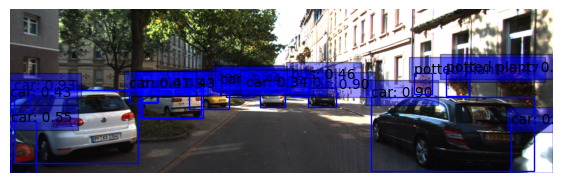

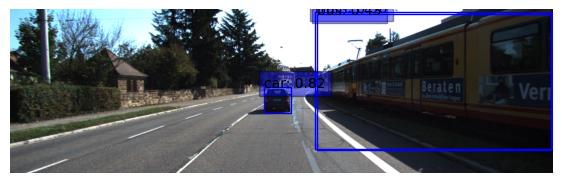

In [ ]:
for idx in range(2):
    image, _ = kitti_train[idx]
    input_image, ratio = prepare_image(image)
    with torch.no_grad():
        detections = inference_model(input_image)[0]

    keep = detections["scores"] > 0.3
    boxes = detections["boxes"][keep] / ratio
    labels = detections["labels"][keep]
    scores = detections["scores"][keep]
    class_names = [COCO_CLASSES[int(l)] for l in labels]

    visualize_detections(image, boxes, class_names, scores)

### 자율주행 시스템 만들기

이미지 경로를 입력받아 Stop / Go 를 반환.

- 사람이 한 명 이상 있는 경우 → `"Stop"`
- 차량의 크기(width or height)가 300px 이상인 경우 → `"Stop"`
- 그 외 → `"Go"`


In [ ]:
os.makedirs(os.path.expanduser('~/aiffel/object_detection/data'), exist_ok=True)

In [ ]:
target_dir = os.path.expanduser('~/aiffel/object_detection/data')
os.makedirs(target_dir, exist_ok=True)

uploaded = files.upload()
for name in uploaded:
    os.replace(name, os.path.join(target_dir, name))

print(os.listdir(target_dir))

Saving go_1.png to go_1.png
Saving go_2.png to go_2.png
Saving go_3.png to go_3.png
Saving go_4.png to go_4.png
Saving go_5.png to go_5.png
Saving person.jpg to person.jpg
Saving stop_1.png to stop_1.png
Saving stop_2.png to stop_2.png
Saving stop_3.png to stop_3.png
Saving stop_4.png to stop_4.png
Saving stop_5.png to stop_5.png
['stop_2.png', 'stop_4.png', 'go_1.png', 'person.jpg', 'go_4.png', 'stop_3.png', 'go_3.png', 'stop_1.png', 'go_5.png', 'stop_5.png', 'go_2.png']


In [ ]:
img_path = os.getenv('HOME') + '/aiffel/object_detection/data/stop_1.png'

def self_drive_assist(img_path, size_limit=280, person_size_limit=60):

    image = Image.open(img_path).convert("RGB")
    input_tensor = transforms.ToTensor()(image).unsqueeze(0)

    inference_model.eval()
    with torch.no_grad():
        detections = inference_model(input_tensor)[0]

    PERSON = {1}
    VEHICLES = {2, 3, 4, 6, 8}
    score_threshold = 0.5

    for box, label, score in zip(detections["boxes"], detections["labels"], detections["scores"]):
        if score < score_threshold:
            continue
        label = int(label)
        x1, y1, x2, y2 = box.tolist()
        w, h = x2 - x1, y2 - y1
        # 사람은 카메라와 충분히 가까울 때(=크게 감지될 때)만 정지
        if label in PERSON and max(w, h) >= person_size_limit:
            return "Stop"
        # 차량의 width 또는 height가 size_limit 이상이면 정지
        if label in VEHICLES and max(w, h) >= size_limit:
            return "Stop"

    return "Go"

print(self_drive_assist(img_path))


Stop


### 진단: 어떤 이미지가 왜 틀렸는지 확인

`test_system`에서 80점이 나온 원인을 찾기 위해, 이미지별로 감지된 사람/차량의 score와 박스 크기(w, h)를 직접 출력

In [ ]:
img_path = os.getenv('HOME') + '/aiffel/object_detection/data/stop_1.png'

def self_drive_assist(img_path, size_limit=280, person_size_limit=60):

    image = Image.open(img_path).convert("RGB")
    input_tensor = transforms.ToTensor()(image).unsqueeze(0)

    inference_model.eval()
    with torch.no_grad():
        detections = inference_model(input_tensor)[0]

    PERSON = {1}
    VEHICLES = {2, 3, 4, 6, 8}
    score_threshold = 0.5

    for box, label, score in zip(detections["boxes"], detections["labels"], detections["scores"]):
        if score < score_threshold:
            continue
        label = int(label)
        x1, y1, x2, y2 = box.tolist()
        w, h = x2 - x1, y2 - y1
        # 사람은 카메라와 충분히 가까울 때(=크게 감지될 때)만 정지
        if label in PERSON and max(w, h) >= person_size_limit:
            return "Stop"
        # 차량의 width 또는 height가 size_limit 이상이면 정지
        if label in VEHICLES and max(w, h) >= size_limit:
            return "Stop"

    return "Go"

print(self_drive_assist(img_path))


Stop


### 자율주행 시스템 평가하기

10장(Stop 5장, Go 5장)에 대해 정답을 맞히는지 확인하고 100점 만점으로 채점.

In [ ]:
def test_system(func):
    work_dir = os.getenv('HOME') + '/aiffel/object_detection/data'
    score = 0
    test_set = [
        ("stop_1.png", "Stop"),
        ("stop_2.png", "Stop"),
        ("stop_3.png", "Stop"),
        ("stop_4.png", "Stop"),
        ("stop_5.png", "Stop"),
        ("go_1.png", "Go"),
        ("go_2.png", "Go"),
        ("go_3.png", "Go"),
        ("go_4.png", "Go"),
        ("go_5.png", "Go"),
    ]

    for image_file, answer in test_set:
        image_path = work_dir + '/' + image_file
        pred = func(image_path)
        if pred == answer:
            score += 10
    print(f"{score}점입니다.")

test_system(self_drive_assist)

100점입니다.


### 전체 코드 실행 플로우

```
KITTI 데이터셋 다운로드 (torchvision.datasets.Kitti)
        │
        ▼
parse_kitti_target (라벨 파싱) ──▶ 시각화(bbox 확인)
        │
        ▼
전처리 파이프라인
  random_flip_horizontal → resize_and_pad_image → convert_to_xywh
        │
        ▼
AnchorBox 생성 ──▶ LabelEncoder (GT ↔ Anchor IoU 매칭 → 학습 타깃 인코딩)
        │
        ▼
RetinaNet (Backbone→FPN→Head) ──▶ RetinaNetLoss(Focal+SmoothL1)
        │
        ▼
학습 루프 (train_loader) ──▶ 체크포인트 저장(latest_checkpoint.pth)
        │
        ▼
체크포인트 로드 ──▶ DecodePredictions(NMS) ──▶ visualize_detections
        │
        ▼
(신뢰도 확보용) torchvision 사전학습 RetinaNet(COCO)
        │
        ▼
self_drive_assist (Person/Vehicle 판단) ──▶ test_system (10장 채점)
```


## 회고

object detection 파이프라인은 모델 하나가 아니라 전처리 → 인코딩 → 모델 → 디코딩 → NMS까지 이어지는 긴 파이프라인이라는 걸 알게 됐다.

또한 오류를 해결하는 과정에서 이번에도 역시 인공지능의 도움을 받게 되었는데, 도움을 받으니 정말 편하다는 것을 다시한번 느끼게 된다..

마지막으로, 오늘 처음으로 flow를 작성해봤는데 코드의 구성을 쉽게 볼 수 있게 정리하는게 좋은 것 같다는 생각이 든다.